Shape: (10000, 12)
         brokered_by    status     price  bed  bath  acre_lot     street  \
1696936      54239.0      sold  275000.0  1.0   1.0       NaN  1617038.0   
2092671      90564.0      sold  399900.0  1.0   1.0       NaN  1497499.0   
742044       53271.0  for_sale   75000.0  NaN   NaN      2.25  1877529.0   
1424136      12926.0      sold  325000.0  3.0   2.0      0.09   892999.0   
812329       79221.0  for_sale  169900.0  NaN   NaN      3.70  1998116.0   

                    city          state  zip_code  house_size prev_sold_date  
1696936            Miami        Florida   33156.0       846.0     2022-02-28  
2092671        San Diego     California   92108.0       667.0     2022-04-28  
742044   Oceola Township       Michigan   48855.0         NaN            NaN  
1424136        Worcester  Massachusetts    1603.0      1409.0     2021-11-29  
812329            Holmen      Wisconsin   54636.0         NaN            NaN  
<class 'pandas.core.frame.DataFrame'>
Index: 10000

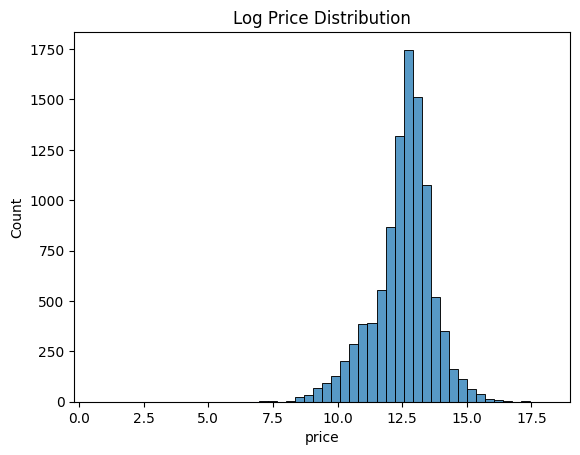

After outlier removal: (9223, 10)


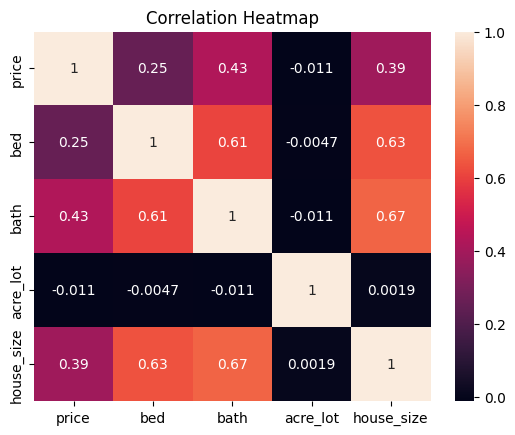

XGBoost MAE: 139968.5946011179
XGBoost RMSE: 201214.9861940863


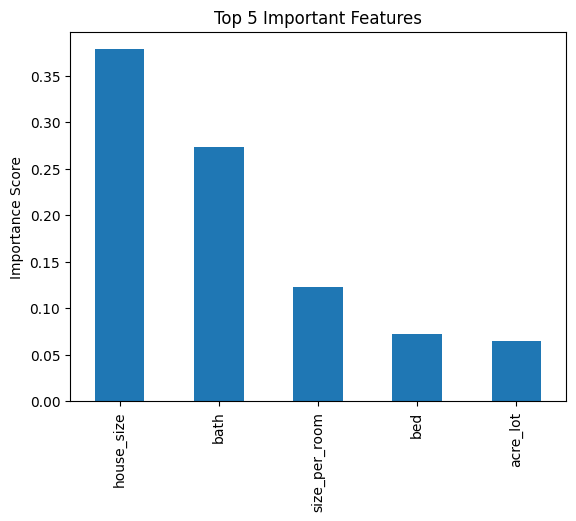

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Tuned XGBoost MAE: 137831.95601287263
Tuned XGBoost RMSE: 200269.13207700892

Model Performance
MAE: 148550.84538698796
RMSE: 209892.27117849138


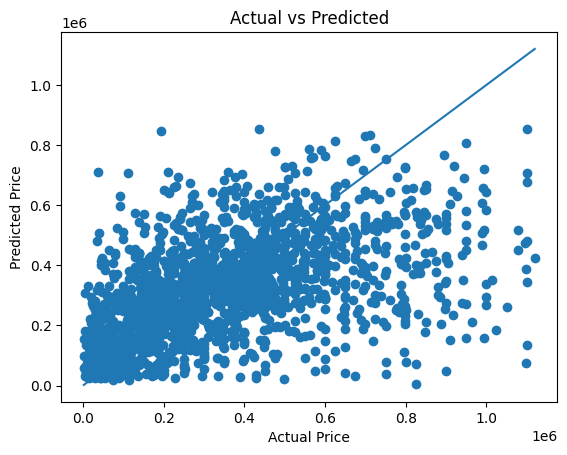

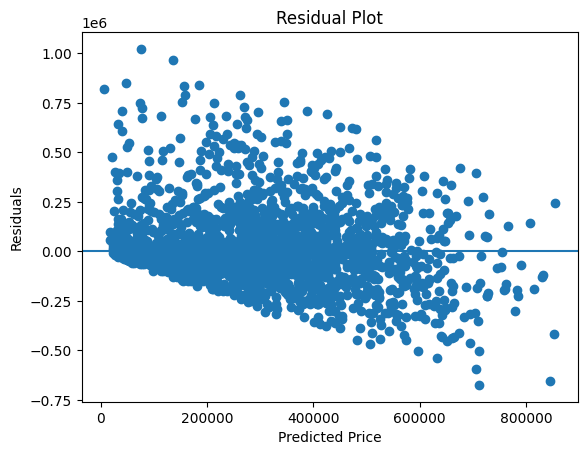

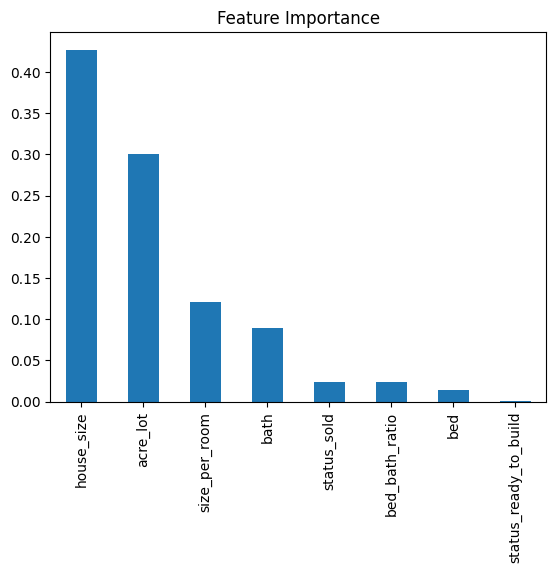

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/content/realtor-data.zip.csv.zip")

# Reduce size for performance
df = df.sample(10000, random_state=42)

print("Shape:", df.shape)
print(df.head())

# =========================
# 3. BASIC EDA
# =========================
print(df.info())
print(df.describe())

# Price Distribution (log scale)
plt.figure()
sns.histplot(np.log1p(df['price'].dropna()), bins=50)
plt.title("Log Price Distribution")
plt.show()

# =========================
# 4. DATA CLEANING
# =========================

# Drop useless columns
df = df.drop(['brokered_by', 'street', 'zip_code', 'prev_sold_date'], axis=1)

# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df['house_size'] = df['house_size'].fillna(df['house_size'].median())
df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].median())
df['bed'] = df['bed'].fillna(df['bed'].median())
df['bath'] = df['bath'].fillna(df['bath'].median())

df = df.dropna(subset=['price'])




# =========================
# FEATURE ENGINEERING (ADD HERE)
# =========================

df['bed_bath_ratio'] = df['bed'] / (df['bath'] + 1)
df['size_per_room'] = df['house_size'] / (df['bed'] + 1)




# =========================
# 5. OUTLIER REMOVAL (IQR)
# =========================
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers(df, 'price')

print("After outlier removal:", df.shape)

# =========================
# 6. FEATURE SELECTION
# =========================
df = df.drop(['city', 'state'], axis=1)

# Encode categorical
df = pd.get_dummies(df, columns=['status'], drop_first=True)

# =========================
# 7. CORRELATION HEATMAP
# =========================
numeric_df = df[['price', 'bed', 'bath', 'acre_lot', 'house_size']]

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 8. DEFINE X AND y (LOG TRANSFORM)
# =========================
X = df.drop('price', axis=1)
y_log = np.log1p(df['price'])

# =========================
# 9. TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)


# =========================
# XGBOOST MODEL
# =========================
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# Prediction
y_pred_log = xgb.predict(X_test)

# Convert back
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)



importance = pd.Series(best_xgb.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(5)

plt.figure()
top_features.plot(kind='bar')
plt.title("Top 5 Important Features")
plt.ylabel("Importance Score")
plt.show()



# =========================
# HYPERPARAMETER TUNING
# =========================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Best model
best_xgb = grid.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("Tuned XGBoost MAE:", mae)
print("Tuned XGBoost RMSE:", rmse)




# =========================
# 10. MODEL (RANDOM FOREST)
# =========================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# =========================
# 11. PREDICTION
# =========================
y_pred_log = rf.predict(X_test)

# Convert back to original scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# =========================
# 12. EVALUATION
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("\nModel Performance")
print("MAE:", mae)
print("RMSE:", rmse)

# =========================
# 13. ACTUAL vs PREDICTED
# =========================
plt.figure()
plt.scatter(y_test_actual, y_pred)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# =========================
# 14. RESIDUAL PLOT
# =========================
residuals = y_test_actual - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# =========================
# 15. FEATURE IMPORTANCE
# =========================
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Final MAE: 137831.95601287263
Final RMSE: 200269.13207700892


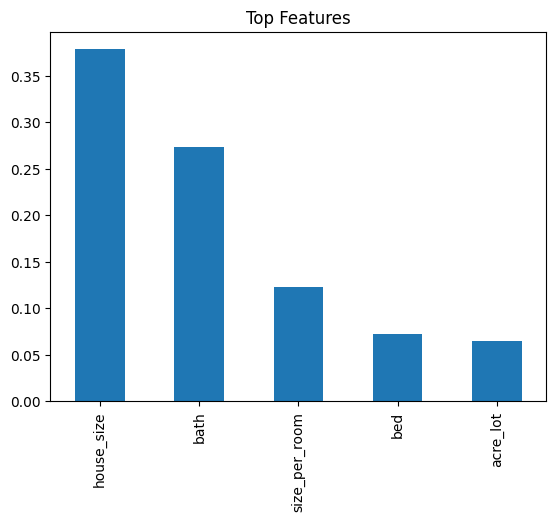

Model saved successfully!


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/content/realtor-data.zip.csv.zip")
df = df.sample(10000, random_state=42)

# =========================
# 3. CLEANING
# =========================
df = df.drop(['brokered_by', 'street', 'zip_code', 'prev_sold_date'], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df['house_size'] = df['house_size'].fillna(df['house_size'].median())
df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].median())
df['bed'] = df['bed'].fillna(df['bed'].median())
df['bath'] = df['bath'].fillna(df['bath'].median())

df = df.dropna(subset=['price'])

# =========================
# 4. FEATURE ENGINEERING
# =========================
df['bed_bath_ratio'] = df['bed'] / (df['bath'] + 1)
df['size_per_room'] = df['house_size'] / (df['bed'] + 1)

# =========================
# 5. OUTLIER REMOVAL
# =========================
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers(df, 'price')

# =========================
# 6. FEATURE SELECTION
# =========================
df = df.drop(['city', 'state'], axis=1)
df = pd.get_dummies(df, columns=['status'], drop_first=True)

# =========================
# 7. DEFINE X & y
# =========================
X = df.drop('price', axis=1)
y = np.log1p(df['price'])

# =========================
# 8. TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 9. MODEL (TUNED XGBOOST)
# =========================
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

# =========================
# 10. EVALUATION
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("Final MAE:", mae)
print("Final RMSE:", rmse)

# =========================
# 11. FEATURE IMPORTANCE
# =========================
importance = pd.Series(best_xgb.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(5).plot(kind='bar')
plt.title("Top Features")
plt.show()

# =========================
# 12. SAVE MODEL
# =========================
joblib.dump(best_xgb, "model.pkl")
print("Model saved successfully!")

In [ ]:
import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("model.pkl")

st.title("🏠 House Price Predictor")

# Inputs
bed = st.slider("Bedrooms", 1, 10, 3)
bath = st.slider("Bathrooms", 1, 10, 2)
size = st.number_input("House Size (sqft)", min_value=100, value=1500)

# Feature engineering (same as training)
bed_bath_ratio = bed / (bath + 1)
size_per_room = size / (bed + 1)

if st.button("Predict Price"):
    input_data = np.array([[bed, bath, size, bed_bath_ratio, size_per_room]])

    pred_log = model.predict(input_data)
    pred = np.expm1(pred_log)

    st.success(f"Estimated Price: ${int(pred[0]):,}")

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.3 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import numpy as np
import joblib

model = joblib.load("model.pkl")

st.title("🏠 House Price Predictor")

bed = st.slider("Bedrooms", 1, 10, 3)
bath = st.slider("Bathrooms", 1, 10, 2)
size = st.number_input("House Size (sqft)", min_value=100, value=1500)

# feature engineering
bed_bath_ratio = bed / (bath + 1)
size_per_room = size / (bed + 1)

if st.button("Predict Price"):
    input_data = np.array([[bed, bath, size, bed_bath_ratio, size_per_room]])

    pred_log = model.predict(input_data)
    pred = np.expm1(pred_log)

    st.success(f"Estimated Price: ${int(pred[0]):,}")

2026-04-07 17:59:42.017 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.808 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-07 17:59:42.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 17:59:42.871 Thread 'MainThread': mi

In [ ]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

model = joblib.load("model.pkl")

st.title("🏠 House Price Predictor")

bed = st.slider("Bedrooms", 1, 10, 3)
bath = st.slider("Bathrooms", 1, 10, 2)
size = st.number_input("House Size (sqft)", min_value=100, value=1500)

# feature engineering
bed_bath_ratio = bed / (bath + 1)
size_per_room = size / (bed + 1)

if st.button("Predict Price"):
    input_data = np.array([[bed, bath, size, bed_bath_ratio, size_per_room]])

    pred_log = model.predict(input_data)
    pred = np.expm1(pred_log)

    st.success(f"Estimated Price: ${int(pred[0]):,}")

Writing app.py
